In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [3]:
import os

In [6]:
os.getcwd()

'c:\\Julius_SSD\\Stanford\\Stanford_3_JuniorYear\\Stanford_3_3_Spring\\CS229\\cs229_rna_folding\\kinfold_simulations\\SLURM'

In [7]:
df = pd.read_parquet('../../modular_setup_improved/synthetic+real_dataset_filtered.parquet')

In [8]:
for col in df.columns:
    if col=='dist' or col=='fpts':
        print(col)

fpts
dist


In [12]:
bin_edges = np.load('../../modular_setup_improved/bin_edges.npy')

min_log_fpt = min(bin_edges)
max_log_fpt = max(bin_edges)

bin_centers = 0.5*(bin_edges[:-1] + bin_edges[1:])

172


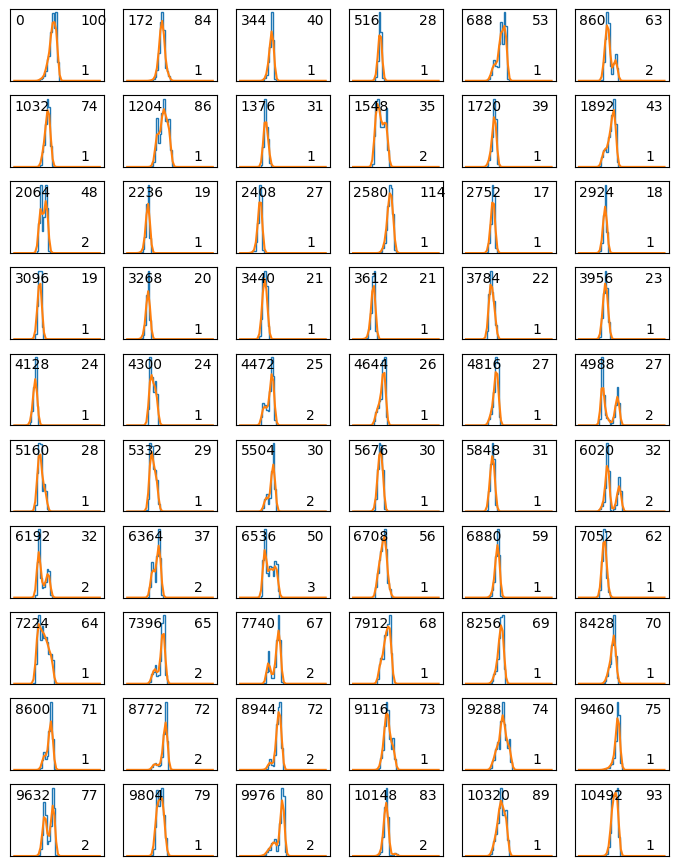

In [13]:
binedges_log_fpt = bin_edges

numpoints_kdegrid = 50
kdegrid_log_fpt = np.linspace(min_log_fpt, max_log_fpt, numpoints_kdegrid)
spacing_kdegrid = kdegrid_log_fpt[1] - kdegrid_log_fpt[0]
stdev = 0.5

def gauss_kernel(kdegrid_log_fpt, mean, stdev):
    return 1/np.sqrt(2*np.pi*stdev**2)*np.exp(-0.5*((kdegrid_log_fpt - mean)/stdev)**2)

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

row_stride = int(len(df)/(n_x*n_y))
print(row_stride)
counter = 0
for row in df.itertuples():
    if row.Index % row_stride == 0:
        data = row.fpts
        where_data_zero = np.where(data == 0)[0]        
        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log10(data[where_data_nonzero])
        
        hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)
        
        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.stairs(hist_log_fpt, binedges_log_fpt)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(row.Index), transform=ax.transAxes, verticalalignment='top')
        ax.text(0.75, 0.95, str(row.length), transform=ax.transAxes, verticalalignment='top')

        # KDE (Kernel Density Estimation)
        kde = np.zeros(numpoints_kdegrid)
        for j in range(log_data.size):
            kde += 1/(log_data.size)*gauss_kernel(kdegrid_log_fpt, log_data[j], stdev)
        
        # number of peaks
        peak_indices, _ = find_peaks(kde)
        num_peaks = len(peak_indices)
        ax.text(0.75, 0.05, str(num_peaks), transform=ax.transAxes, verticalalignment='bottom')

        ax.plot(kdegrid_log_fpt, kde)

        counter += 1
        if counter == n_x*n_y:
            break

#plt.savefig('hist_kde_log_fpt.pdf', bbox_inches='tight', pad_inches=0.25)

In [14]:
df['num_peaks'] = None

numpoints_kdegrid = 50
kdegrid_log_fpt = np.linspace(min_log_fpt, max_log_fpt, numpoints_kdegrid)
spacing_kdegrid = kdegrid_log_fpt[1] - kdegrid_log_fpt[0]
stdev = 0.5

def gauss_kernel(kdegrid_log_fpt, mean, stdev):
    return 1/np.sqrt(2*np.pi*stdev**2)*np.exp(-0.5*((kdegrid_log_fpt - mean)/stdev)**2)

row_stride = 100
for row in df.itertuples():
    if row.Index % row_stride == 0:
        print(row.Index)
    data = row.fpts
    where_data_zero = np.where(data == 0)[0]        
    where_data_nonzero = np.where(data != 0)[0]
    log_data = np.log10(data[where_data_nonzero])

    # KDE (Kernel Density Estimation)
    kde = np.zeros(numpoints_kdegrid)
    for j in range(log_data.size):
        kde += 1/(log_data.size)*gauss_kernel(kdegrid_log_fpt, log_data[j], stdev)
    
    # number of peaks
    peak_indices, _ = find_peaks(kde)
    num_peaks = len(peak_indices)
    df.loc[row.Index, 'num_peaks'] = num_peaks

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7800
7900
8000
8300
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900


In [36]:
num_peaks_array = np.array(df['num_peaks'])

(array([7795.,    0.,    0.,    0.,    0., 2431.,    0.,    0.,    0.,
          99.]),
 array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ]),
 <BarContainer object of 10 artists>)

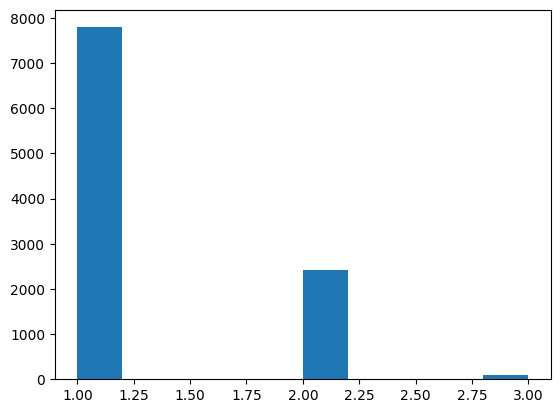

In [37]:
plt.hist(num_peaks_array)

In [38]:
df.to_parquet('../modular_setup_improved/synthetic+real_dataset_filtered_numpeaks.parquet')

In [15]:
df = pd.read_parquet('../../modular_setup_improved/synthetic+real_dataset_filtered_numpeaks.parquet')

(array([7795.,    0.,    0.,    0.,    0., 2431.,    0.,    0.,    0.,
          99.]),
 array([1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4, 2.6, 2.8, 3. ]),
 <BarContainer object of 10 artists>)

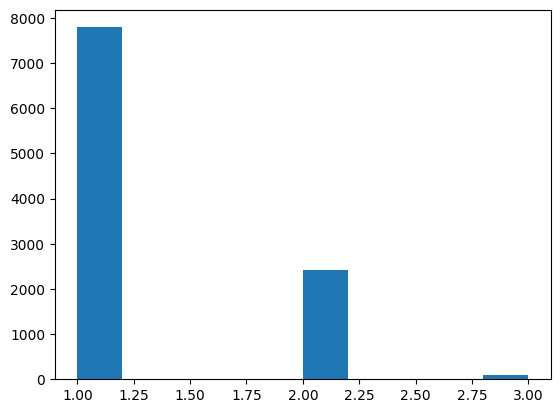

In [17]:
plt.hist(np.array(df['num_peaks']))

In [18]:
mask_1or2peaks = df['num_peaks'].apply(lambda n: (n==1) or (n==2))
mask_1or2peaks = mask_1or2peaks.to_frame()
print(np.sum(mask_1or2peaks))

num_peaks    10226
dtype: int64


c:\Users\Julius\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [20]:
mask_1or2peaks.to_parquet('../../modular_setup_improved_numpeaks/mask_1or2peaks.parquet')

In [39]:
mask_2peaks = df['num_peaks'].apply(lambda n: (n==2))

In [122]:
mask_2peaks = mask_2peaks.to_frame()

In [123]:
np.sum(mask_2peaks)

c:\Users\Julius\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


num_peaks    2431
dtype: int64

In [124]:
os.getcwd()

'c:\\Julius_SSD\\Stanford\\Stanford_3_JuniorYear\\Stanford_3_3_Spring\\CS229\\cs229_rna_folding\\modular_setup_improved_kmn'

In [125]:
mask_2peaks.to_parquet('../modular_setup_improved/mask_2peaks.parquet')

In [126]:
data_mask = pd.read_parquet('../modular_setup_improved/mask_2peaks.parquet')

In [127]:
import torch
from pathlib import Path

In [128]:
os.getcwd()

'c:\\Julius_SSD\\Stanford\\Stanford_3_JuniorYear\\Stanford_3_3_Spring\\CS229\\cs229_rna_folding\\modular_setup_improved_kmn'

In [76]:
EMBEDDING_PATH = "../modular_setup_improved/all_fm-rna_embeddings_filtered.pt"


In [77]:
embeddings_dict = torch.load(EMBEDDING_PATH)

In [78]:
embeddings_dict

{'0': tensor([[ 0.0345, -0.1729, -0.0209,  ..., -0.4258, -0.0027,  0.0288],
         [-0.1627, -0.0816,  0.1722,  ..., -0.0771, -0.0380,  0.0070],
         [ 0.0473, -0.0453,  0.1980,  ..., -0.1315,  0.0228, -0.0656],
         ...,
         [-0.0969, -0.0868,  0.2532,  ..., -0.1976, -0.0088, -0.1013],
         [ 0.1278,  0.0583,  0.3057,  ..., -0.1479, -0.0108, -0.0613],
         [-0.0669,  0.1414,  0.1653,  ..., -0.0996,  0.0723,  0.0224]],
        dtype=torch.float16),
 '1': tensor([[-0.2876,  0.1235, -0.0356,  ..., -0.4185, -0.1210, -0.1025],
         [ 0.1305, -0.2406,  0.0402,  ..., -0.3054,  0.0746,  0.0400],
         [ 0.0452, -0.1907,  0.0061,  ..., -0.1230,  0.1412, -0.0620],
         ...,
         [ 0.2129, -0.2034,  0.3408,  ..., -0.1891,  0.0106,  0.0356],
         [ 0.1946,  0.0995,  0.2177,  ..., -0.3098,  0.1671, -0.1404],
         [ 0.2499, -0.1344,  0.2507,  ..., -0.2035,  0.1411, -0.0898]],
        dtype=torch.float16),
 '2': tensor([[ 0.0638, -0.2712,  0.1423,  ..., 

In [129]:
np.array(data_mask['num_peaks'])

array([False, False, False, ..., False, False, False])

In [130]:
df_2peaksonly = df[np.array(data_mask['num_peaks'])]

In [131]:
len(df_2peaksonly)

2431

In [132]:
row_keys = [str(idx) for idx in df_2peaksonly.index.tolist()]

In [133]:
embeddings_dict.keys()

dict_keys(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', 

In [136]:
data_mask['num_peaks'][8794]

np.False_

In [137]:
embeddings_dict_aftermask = {}
for key in embeddings_dict.keys():
    if data_mask['num_peaks'][int(key)]:
        embeddings_dict_aftermask[key] = embeddings_dict[key]

In [138]:
embeddings_dict_aftermask

{'3': tensor([[-0.1029,  0.0293,  0.1198,  ..., -0.3438, -0.0424,  0.0347],
         [-0.0589, -0.1501,  0.1788,  ..., -0.2957, -0.0396, -0.0776],
         [ 0.0844, -0.2240,  0.1482,  ..., -0.2367, -0.0683, -0.0999],
         ...,
         [-0.0462, -0.0774,  0.4221,  ..., -0.1044, -0.1399, -0.0878],
         [ 0.0158,  0.0128,  0.2673,  ..., -0.2097, -0.0692, -0.0569],
         [-0.0534, -0.0108,  0.1145,  ..., -0.2561, -0.1477, -0.1812]],
        dtype=torch.float16),
 '5': tensor([[-0.0460,  0.0871,  0.1434,  ..., -0.4497, -0.1687, -0.1129],
         [ 0.4084, -0.0622,  0.1708,  ..., -0.1820,  0.1309, -0.0431],
         [ 0.2042,  0.1573,  0.1522,  ..., -0.2937, -0.1467, -0.5005],
         ...,
         [-0.1429, -0.0192,  0.1284,  ..., -0.1294,  0.0942, -0.1031],
         [-0.1659,  0.0876,  0.1508,  ..., -0.0742,  0.1289, -0.1909],
         [ 0.0917, -0.1152, -0.0194,  ..., -0.3691, -0.2343, -0.0203]],
        dtype=torch.float16),
 '9': tensor([[-0.0057,  0.0254,  0.1255,  ..., 